Libraries and helper functions:

In [1]:
import sys
import os
sys.path.append(os.path.abspath('../..')) 

import numpy as np
import matplotlib.pyplot as plt
import pyroomacoustics as pra
from scipy.signal import lfilter
from helpers.adaptMultichannel import adaptMultichannel

caca


Simulation:

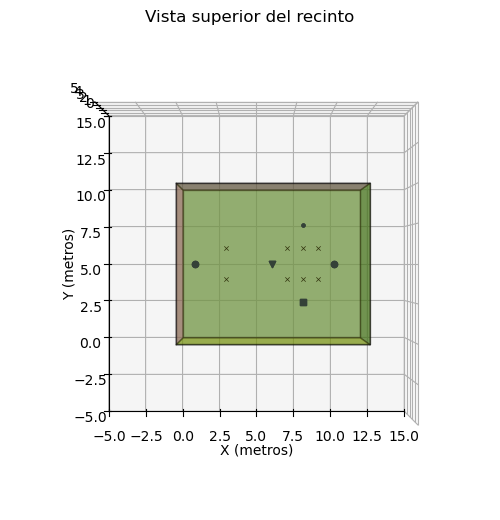

In [2]:
# Create a room
fs = 12000
room = pra.ShoeBox([12, 10, 5], fs=fs, max_order=0)

# Noise source
room.add_source([1, 5, 2.5])

# Reference microphones
room.add_microphone([3, 4, 2.5], fs=fs)
room.add_microphone([3, 6, 2.5], fs=fs)

# Actuators
room.add_source([8, 2.5, 2.5])
room.add_source([6, 5, 2.5])
room.add_source([8, 7.5, 2.5])
room.add_source([10, 5, 2.5])

# Error microphones
room.add_microphone([7, 4, 2.5], fs=fs)
room.add_microphone([7, 6, 2.5], fs=fs)
room.add_microphone([8, 4, 2.5], fs=fs)
room.add_microphone([8, 6, 2.5], fs=fs)
room.add_microphone([9, 4, 2.5], fs=fs)
room.add_microphone([9, 6, 2.5], fs=fs)

fig, ax = room.plot()
ax.view_init(elev=90, azim=-90)
ax.set_title("Vista superior del recinto")
ax.set_xlim(-5, 15)
ax.set_ylim(-5, 15)
plt.grid(True)
plt.xlabel('X (metros)')
plt.ylabel('Y (metros)')
plt.show()

Obtain RIRs:

In [3]:
nReferenceMics = 2
nActuators = 4
nErrorMics = 6

room.compute_rir()
referencePaths = [room.rir[m][0] for m in range(nReferenceMics)]
primaryPaths = [room.rir[m][0] for m in range(nReferenceMics, nReferenceMics + nErrorMics)]
secondaryPaths = [[room.rir[m][s] for s in range(1, nActuators + 1)] for m in range(nReferenceMics, nReferenceMics + nErrorMics)]

# Shape RIRs for efficient convolution
referencePaths = np.array([
    np.pad(h, (0, max(len(h) for h in referencePaths) - len(h)))
    for h in referencePaths
])

primaryPaths = np.array([
    np.pad(h, (0, max(len(h) for h in primaryPaths) - len(h)))
    for h in primaryPaths
])

maxLen = max(len(h) for row in secondaryPaths for h in row)
secondaryPaths = np.array([
    [np.pad(h, (0, maxLen - len(h))) for h in row]
    for row in secondaryPaths
])

print("Reference paths shape: ", referencePaths.shape)
print("Primary paths shape: ", primaryPaths.shape)
print("Secondary paths shape: ", secondaryPaths.shape)

Reference paths shape:  (2, 161)
Primary paths shape:  (6, 365)
Secondary paths shape:  (6, 4, 210)


Algorithm:

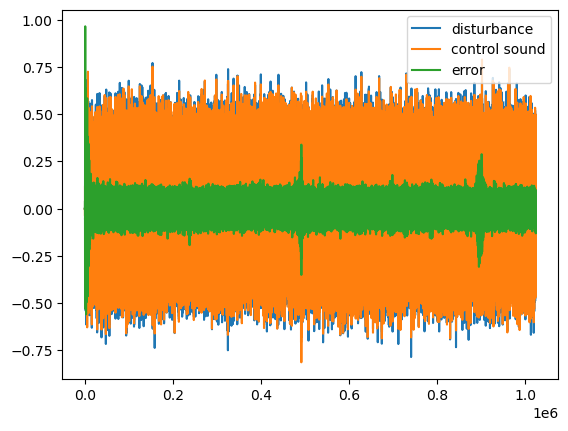

In [ ]:
# Disturbance
blocklength = 1024
nBlocks = 1000
N = nBlocks * blocklength
t = np.arange(N) * (1/fs)
x = np.random.randn(N)

# Adaptive filter matrix definition
nTaps = 512
wFilter = np.ones((nActuators, nReferenceMics, nTaps)) * 0.01
mu = 1

# Spectrums and buffers for online convolution
Mr = referencePaths.shape[1]
Nr = blocklength + Mr - 1
rSpectrum = np.fft.rfft(referencePaths, n=Nr, axis=-1)
rBuffer = np.zeros(Mr - 1)

Mp = primaryPaths.shape[1]
Np = blocklength + Mp - 1
pSpectrum = np.fft.rfft(primaryPaths, n=Np, axis=-1)
pBuffer = np.zeros(Mp - 1)

Mw = nTaps
Nw = blocklength + Mw - 1
wBuffer = np.zeros((nReferenceMics, Mw - 1))

Mg = secondaryPaths.shape[2]
Ng = blocklength + Mg - 1
gSpectrum = np.fft.rfft(secondaryPaths, n=Ng, axis=-1)
gBuffer = np.zeros((nActuators, Mg - 1))

secondaryPathsHat = secondaryPaths  # Ideal case where G = GHat
MgHat = secondaryPathsHat.shape[2]
NgHat = blocklength + MgHat - 1
gHatSpectrum = np.fft.rfft(secondaryPathsHat, n=NgHat, axis=-1)
gHatBuffer = np.zeros((nReferenceMics, MgHat - 1))

# For testing
xRef = np.zeros((nReferenceMics, N))
d = np.zeros((nErrorMics, N))
u = np.zeros((nActuators, N))
y = np.zeros((nErrorMics, N))
e = np.zeros((nErrorMics, N))

for k in range(nBlocks):
    # Block samples of X (simulation)
    xSignal = x[k*blocklength : (k+1)*blocklength]
    
    ################## Physical signals ##################

    # Reference signals (simulation)
    xSignalExt = np.concatenate([rBuffer, xSignal])
    xSpectrum = np.fft.rfft(xSignalExt, n=Nr)
    rSignalsSpectrum = rSpectrum * xSpectrum
    rSignalsExt = np.fft.irfft(rSignalsSpectrum, n=Nr, axis=-1)
    rSignals = rSignalsExt[:, Mr - 1:]
    rBuffer = xSignalExt[-(Mr - 1):]
        
    # Disturbance signals (simulation)
    xSignalExt = np.concatenate([pBuffer, xSignal])
    xSpectrum = np.fft.rfft(xSignalExt, n=Np)
    dSignalsSpectrum = pSpectrum * xSpectrum
    dSignalsExt = np.fft.irfft(dSignalsSpectrum, n=Np, axis=-1)
    dSignals = dSignalsExt[:, Mp - 1:]
    pBuffer = xSignalExt[-(Mp - 1):]
    
    # Actuators signals
    rSignalsExt = np.concatenate([wBuffer, rSignals], axis=1)   
    rSignalsSpectrum = np.fft.rfft(rSignalsExt, n=Nw, axis=-1)
    wSpectrum = np.fft.rfft(wFilter, n=Nw, axis=-1)
    aSignalsSpectrum = np.einsum('mkf,kf->mf', wSpectrum, rSignalsSpectrum)
    aSignalsExt = np.fft.irfft(aSignalsSpectrum, n=Nw, axis=-1)
    aSignals = aSignalsExt[:, Mw - 1:]
    wBuffer = rSignalsExt[:, -(Mw - 1):]
    
    # Control and Errors signals (simulation)
    aSignalsExt = np.concatenate([gBuffer, aSignals], axis=1)
    aSignalsSpectrum = np.fft.rfft(aSignalsExt, n=Ng, axis=-1)
    cSignalsSpectrum = np.einsum('emf,mf->ef', gSpectrum, aSignalsSpectrum)
    cSignalsExt = np.fft.irfft(cSignalsSpectrum, n=Ng, axis=-1)
    cSignals = cSignalsExt[:, Mg - 1:]
    gBuffer = aSignalsExt[:, -(Mg - 1):]
       
    eSignals = dSignals - cSignals
    
    ################## Algorithm ##################

    # Compute the filtered reference matrix
    rSignalsExt = np.concatenate([gHatBuffer, rSignals], axis=1)   
    rSignalsSpectrum = np.fft.rfft(rSignalsExt, n=NgHat, axis=-1)   
    frSignalsSpectrum = np.einsum('emf,kf->emkf', gHatSpectrum, rSignalsSpectrum)   # Extra time could be saved here, since this fft is calculated inside adaptMultichannel
    frSignalsExt = np.fft.irfft(frSignalsSpectrum, n=NgHat, axis=-1)
    frSignals = frSignalsExt[..., MgHat - 1:]
    gHatBuffer = rSignalsExt[:, -(MgHat - 1):]

    # LMS algorithm
    wFilter = adaptMultichannel(
        frSignals,
        eSignals,
        nTaps,
        blocklength,
        wFilter,
        mu
    )
    
    ################## For testing ##################
    start = k * blocklength
    end = (k + 1) * blocklength

    xRef[:, start:end] = rSignals
    d[:, start:end] = dSignals
    u[:, start:end] = aSignals
    y[:, start:end] = cSignals
    e[:, start:end] = eSignals

plt.plot(d[0], label="disturbance")
plt.plot(y[0], label="control sound")
plt.plot(e[0], label="error")
plt.legend()
plt.show()
